# H&M SQL-driven Exploratory Data Analysis (EDA)
This notebook answers **10 Important Business Questions** using a combination of **SQL queries** for aggregation and **Python (Pandas/Seaborn)** for visualization.

In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set aesthetic parameters
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

# Connect to the SQLite Database
db_path = r"D:\Imarticus Learning- PGA 45\GitHub Projects\h & m db\hm_database.db"
conn = sqlite3.connect(db_path)
print("Connected to the database successfully.")

Connected to the database successfully.


,prod_name,total_sold
0,Jade HW Skinny Denim TRS,31848
1,Jade HW Skinny Denim TRS,18031
2,SUPREME RW tights,17815
3,7p Basic Shaftless,16020
4,Tilda tank,15695
5,Tilly (1),15404
6,Pluto RW slacks (1),14832
7,Jade HW Skinny Denim TRS,13903
8,Greta Thong Mynta Low 3p,13873
9,7p Basic Shaftless,13660


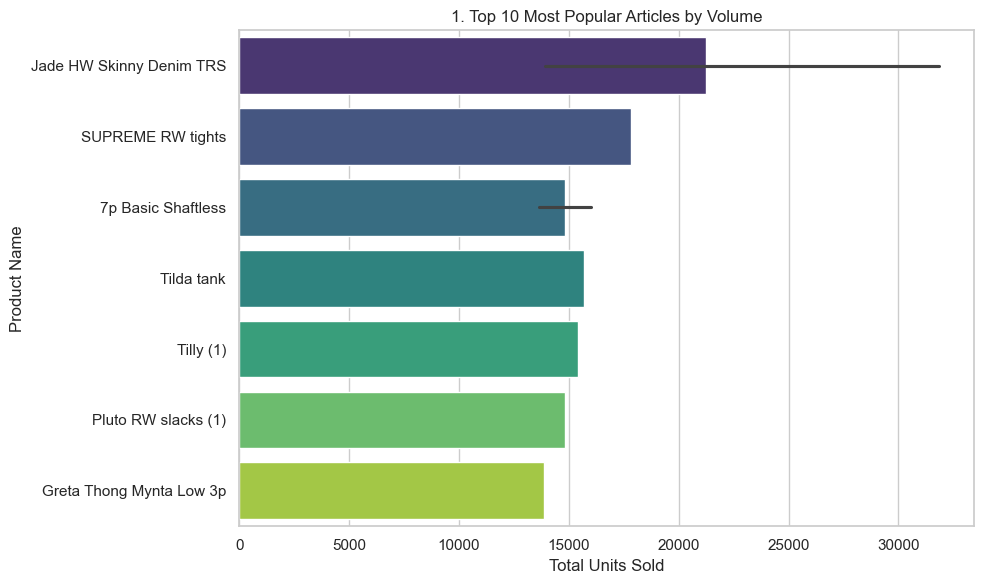

In [2]:
# 1. Top 10 Most Popular Articles by Volume
query1 = '''
SELECT a.prod_name, COUNT(t.article_id) as total_sold
FROM transactions t
JOIN articles a ON t.article_id = a.article_id
GROUP BY t.article_id
ORDER BY total_sold DESC
LIMIT 10;
'''
df1 = pd.read_sql_query(query1, conn)
display(df1)

plt.figure(figsize=(10, 6))
sns.barplot(data=df1, x='total_sold', y='prod_name', palette='viridis')
plt.title('1. Top 10 Most Popular Articles by Volume')
plt.xlabel('Total Units Sold')
plt.ylabel('Product Name')
plt.tight_layout()
plt.show()

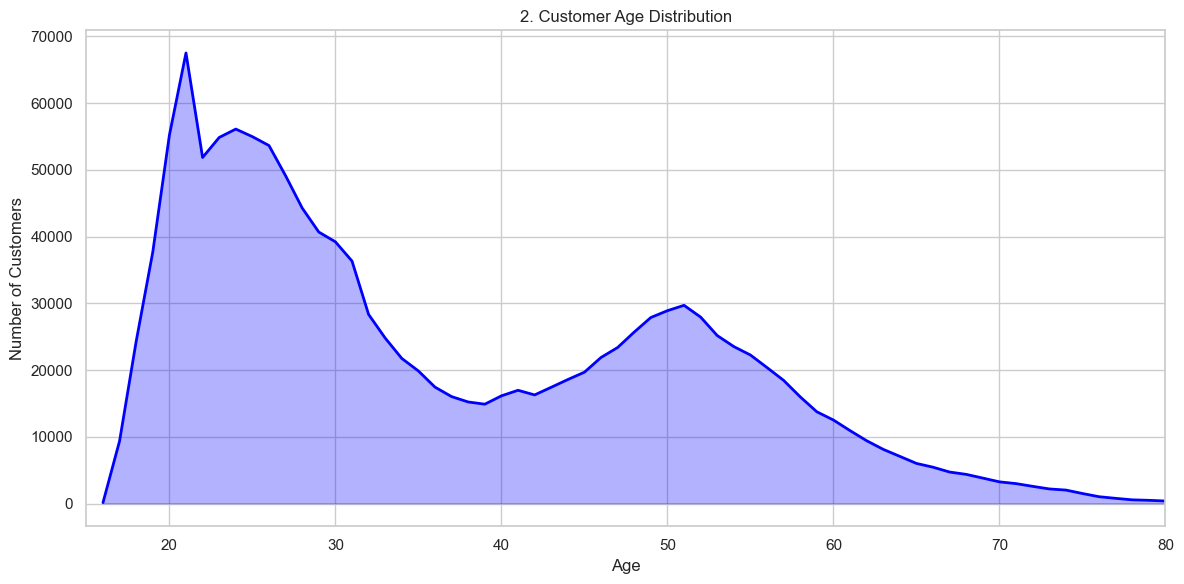

In [3]:
# 2. Customer Age Distribution
query2 = '''
SELECT age, COUNT(customer_id) as customer_count
FROM customers
WHERE age IS NOT NULL
GROUP BY age
ORDER BY age;
'''
df2 = pd.read_sql_query(query2, conn)

plt.figure(figsize=(12, 6))
sns.lineplot(data=df2, x='age', y='customer_count', color='blue', linewidth=2)
plt.fill_between(df2['age'], df2['customer_count'], alpha=0.3, color='blue')
plt.title('2. Customer Age Distribution')
plt.xlabel('Age')
plt.ylabel('Number of Customers')
plt.xlim(15, 80)
plt.tight_layout()
plt.show()

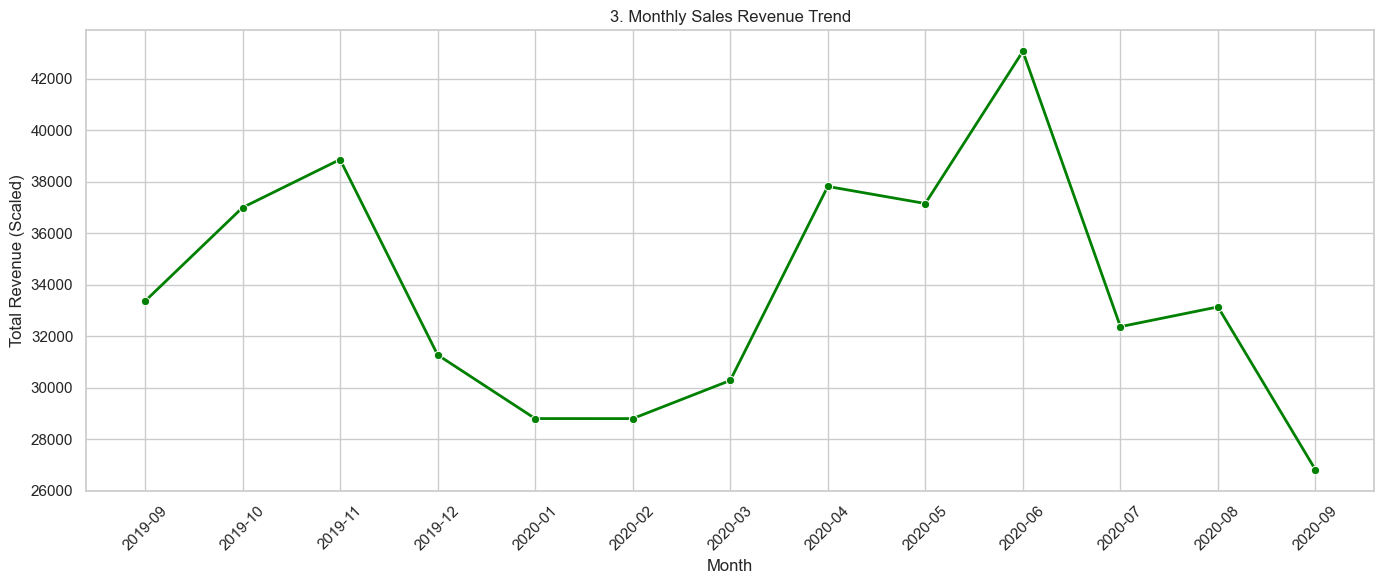

In [4]:
# 3. Monthly Sales Revenue Trend
query3 = '''
SELECT strftime('%Y-%m', t_dat) as month, SUM(price) as total_revenue
FROM transactions
GROUP BY month
ORDER BY month;
'''
df3 = pd.read_sql_query(query3, conn)

plt.figure(figsize=(14, 6))
sns.lineplot(data=df3, x='month', y='total_revenue', marker='o', color='green', linewidth=2)
plt.title('3. Monthly Sales Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Total Revenue (Scaled)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

,prod_name,total_revenue
0,Jade HW Skinny Denim TRS,1024.656678
1,SUPREME RW tights,576.720339
2,Jade HW Skinny Denim TRS,576.691203
3,Perrie Slim Mom Denim TRS,486.479441
4,Pluto RW slacks (1),477.967847
5,Mariette Blazer,456.577407
6,Jade HW Skinny Denim TRS,449.816915
7,Luna skinny RW,404.262119
8,Mom Fit Ultra HW,381.869000
9,Vintage Slim HW ankle consc.,370.243864


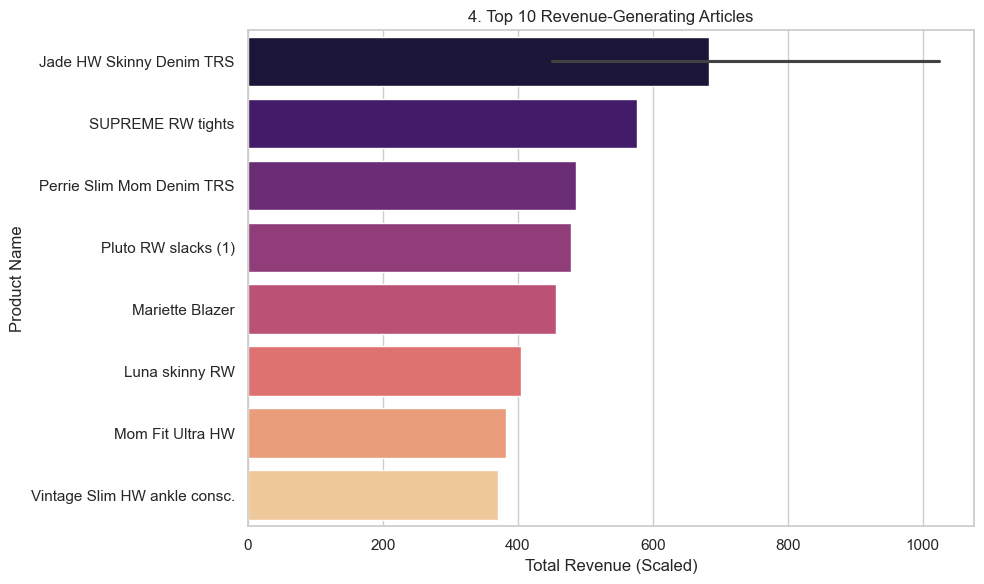

In [5]:
# 4. Top 10 Revenue-Generating Articles
query4 = '''
SELECT a.prod_name, SUM(t.price) as total_revenue
FROM transactions t
JOIN articles a ON t.article_id = a.article_id
GROUP BY t.article_id
ORDER BY total_revenue DESC
LIMIT 10;
'''
df4 = pd.read_sql_query(query4, conn)
display(df4)

plt.figure(figsize=(10, 6))
sns.barplot(data=df4, x='total_revenue', y='prod_name', palette='magma')
plt.title('4. Top 10 Revenue-Generating Articles')
plt.xlabel('Total Revenue (Scaled)')
plt.ylabel('Product Name')
plt.tight_layout()
plt.show()

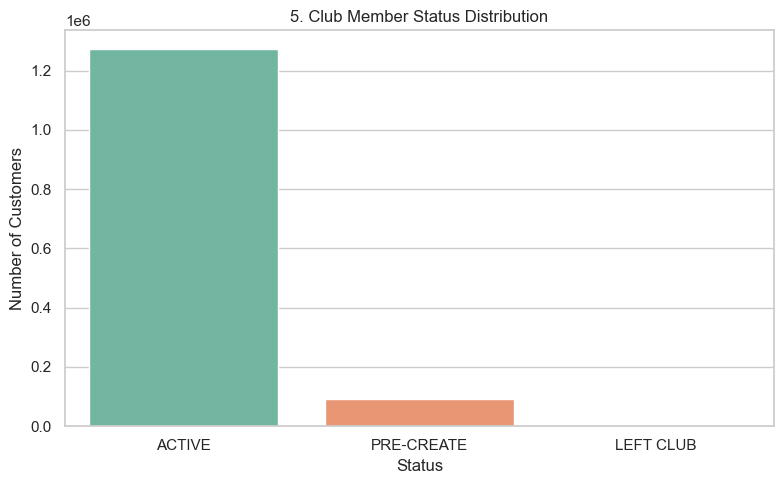

In [6]:
# 5. Customer Club Member Status Distribution
query5 = '''
SELECT club_member_status, COUNT(customer_id) as count
FROM customers
WHERE club_member_status IS NOT NULL
GROUP BY club_member_status
ORDER BY count DESC;
'''
df5 = pd.read_sql_query(query5, conn)

plt.figure(figsize=(8, 5))
sns.barplot(data=df5, x='club_member_status', y='count', palette='Set2')
plt.title('5. Club Member Status Distribution')
plt.xlabel('Status')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()

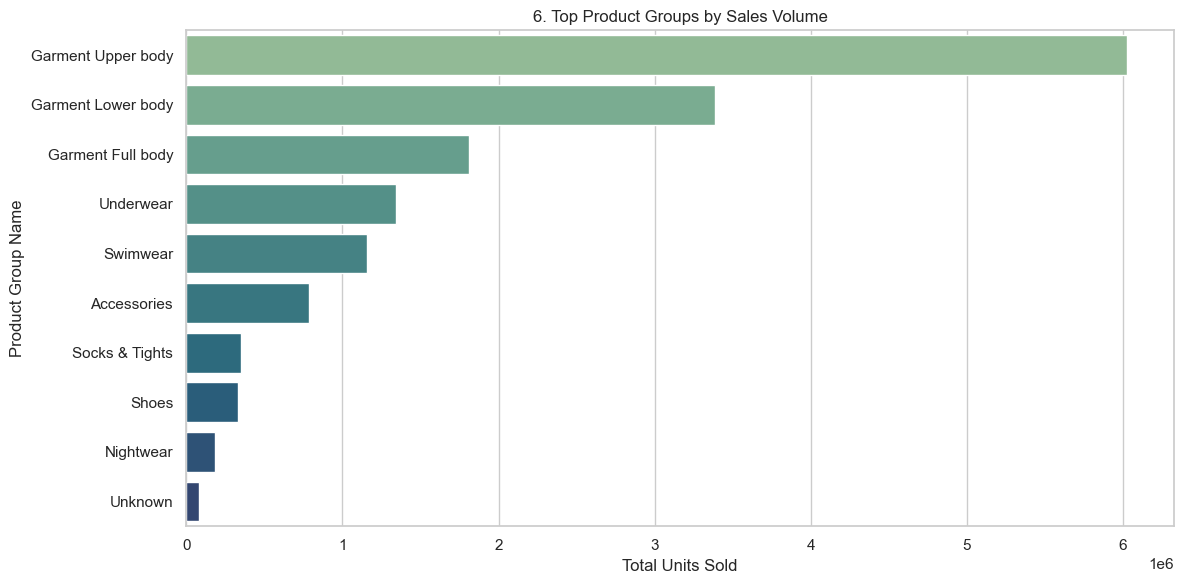

In [7]:
# 6. Top Product Groups by Sales Volume
query6 = '''
SELECT a.product_group_name, COUNT(t.article_id) as total_sold
FROM transactions t
JOIN articles a ON t.article_id = a.article_id
GROUP BY a.product_group_name
ORDER BY total_sold DESC
LIMIT 10;
'''
df6 = pd.read_sql_query(query6, conn)

plt.figure(figsize=(12, 6))
sns.barplot(data=df6, x='total_sold', y='product_group_name', palette='crest')
plt.title('6. Top Product Groups by Sales Volume')
plt.xlabel('Total Units Sold')
plt.ylabel('Product Group Name')
plt.tight_layout()
plt.show()

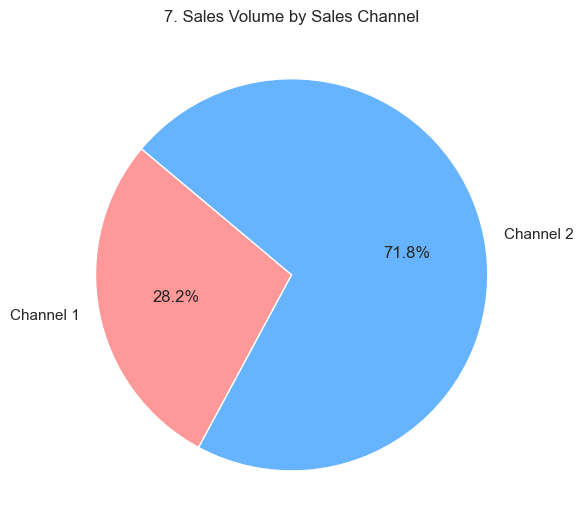

In [8]:
# 7. Sales Volume by Sales Channel
query7 = '''
SELECT sales_channel_id, COUNT(t_dat) as total_transactions
FROM transactions
GROUP BY sales_channel_id;
'''
df7 = pd.read_sql_query(query7, conn)

plt.figure(figsize=(6, 6))
plt.pie(df7['total_transactions'], labels=['Channel ' + str(x) for x in df7['sales_channel_id']], autopct='%1.1f%%', startangle=140, colors=['#ff9999','#66b3ff'])
plt.title('7. Sales Volume by Sales Channel')
plt.tight_layout()
plt.show()

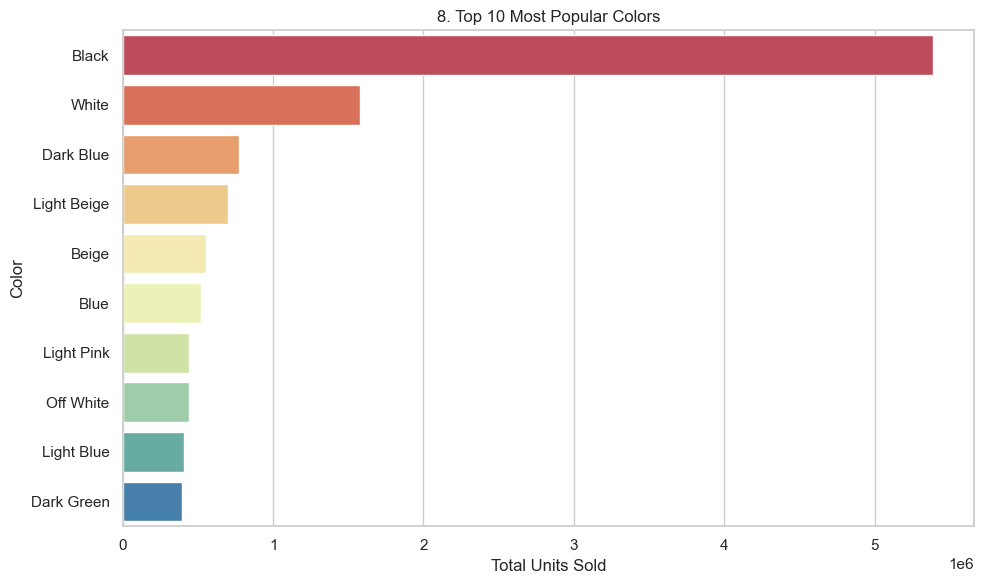

In [9]:
# 8. Top 10 Most Popular Colors
query8 = '''
SELECT a.colour_group_name, COUNT(t.article_id) as total_sold
FROM transactions t
JOIN articles a ON t.article_id = a.article_id
GROUP BY a.colour_group_name
ORDER BY total_sold DESC
LIMIT 10;
'''
df8 = pd.read_sql_query(query8, conn)

plt.figure(figsize=(10, 6))
sns.barplot(data=df8, x='total_sold', y='colour_group_name', palette='Spectral')
plt.title('8. Top 10 Most Popular Colors')
plt.xlabel('Total Units Sold')
plt.ylabel('Color')
plt.tight_layout()
plt.show()

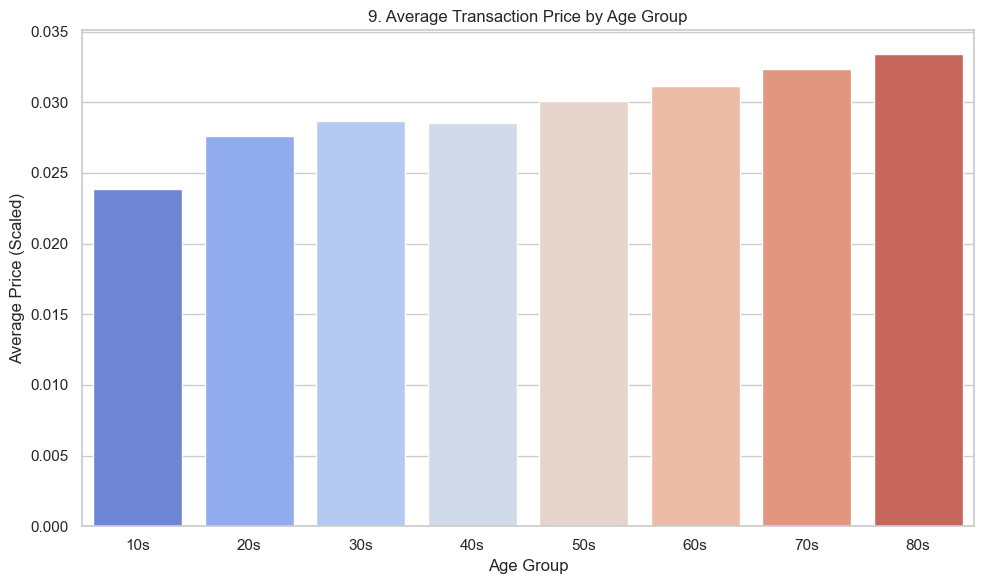

In [10]:
# 9. Average Transaction Price by Age Group
query9 = '''
SELECT CAST(c.age / 10 AS INT) * 10 AS age_group, AVG(t.price) as avg_price
FROM transactions t
JOIN customers c ON t.customer_id = c.customer_id
WHERE c.age IS NOT NULL
GROUP BY age_group
ORDER BY age_group;
'''
df9 = pd.read_sql_query(query9, conn)
df9 = df9[(df9['age_group'] >= 10) & (df9['age_group'] <= 80)]
df9['age_group'] = df9['age_group'].astype(str) + 's'

plt.figure(figsize=(10, 6))
sns.barplot(data=df9, x='age_group', y='avg_price', palette='coolwarm')
plt.title('9. Average Transaction Price by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Average Price (Scaled)')
plt.tight_layout()
plt.show()

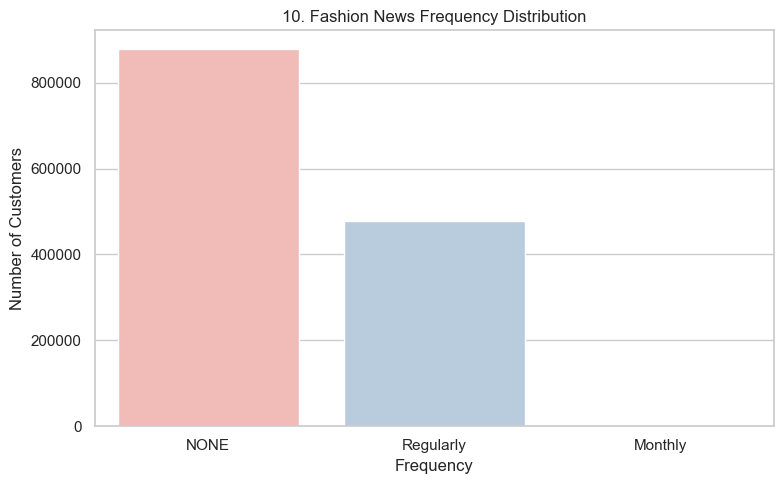

In [11]:
# 10. Fashion News Frequency Distribution
query10 = '''
SELECT fashion_news_frequency, COUNT(customer_id) as count
FROM customers
WHERE fashion_news_frequency IS NOT NULL
GROUP BY fashion_news_frequency
ORDER BY count DESC;
'''
df10 = pd.read_sql_query(query10, conn)

plt.figure(figsize=(8, 5))
sns.barplot(data=df10, x='fashion_news_frequency', y='count', palette='Pastel1')
plt.title('10. Fashion News Frequency Distribution')
plt.xlabel('Frequency')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()

In [12]:
# Close the connection when done
conn.close()
print("Connection closed.")

Connection closed.
